# **Stock Price Prediction using Machine learning**
### Task 2 Project 01


## **1. Importing Libraries**



In [32]:
# Basic libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Install optional libraries if missing
try:
    from xgboost import XGBRegressor
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
except ImportError:
    !pip install lightgbm -q
    from lightgbm import LGBMRegressor

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError:
    !pip install tensorflow -q
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

pd.set_option("display.max_columns", None)

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## **2. Load Dataset**


In [2]:
DATASET_CANDIDATES = [
    "NSE-Tata_Global_Beverages_Limited.csv",
    "NSE-Tata_Global_Beverages_Limited(1).csv"
]

def find_dataset_file(candidates):
    for file in candidates:
        if os.path.exists(file):
            return file
    return None

dataset_path = find_dataset_file(DATASET_CANDIDATES)

# If file is not already available, ask user to upload it in Google Colab
if dataset_path is None:
    try:
        from google.colab import files
        print("Please upload the stock dataset CSV file.")
        uploaded = files.upload()
        dataset_path = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError(
            "Dataset file not found. Please upload NSE-Tata_Global_Beverages_Limited.csv"
        )

print("Dataset path:", dataset_path)

# Load dataset
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
df.head()

Dataset path: NSE-Tata_Global_Beverages_Limited.csv
Dataset loaded successfully.


,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


## **3. Dataset Description & Inspection**


In [3]:
print("Dataset Shape:", df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1235, 8)

Dataset Columns:
['Date', 'Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity', 'Turnover (Lacs)']

Data Types:
Date                     object
Open                    float64
High                    float64
Low                     float64
Last                    float64
Close                   float64
Total Trade Quantity    float64
Turnover (Lacs)         float64
dtype: object

First 5 Rows:


,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05



Last 5 Rows:


,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
1230,2013-10-14,160.85,161.45,157.70,159.3,159.45,1281419.0,2039.09
1231,2013-10-11,161.15,163.45,159.00,159.8,160.05,1880046.0,3030.76
1232,2013-10-10,156.00,160.80,155.85,160.3,160.15,3124853.0,4978.80
1233,2013-10-09,155.70,158.20,154.15,155.3,155.55,2049580.0,3204.49
1234,2013-10-08,157.00,157.80,155.20,155.8,155.80,1720413.0,2688.94



Missing Values:


,0
Date,0
Open,0
High,0
Low,0
Last,0
Close,0
Total Trade Quantity,0
Turnover (Lacs),0



Duplicate Rows: 0


In [4]:
# Check date range before cleaning
date_preview = pd.to_datetime(df["Date"], errors="coerce")
print("Minimum Date:", date_preview.min())
print("Maximum Date:", date_preview.max())

print("\nTarget column for final prediction will be created as: Next_Close")
print("Original price column used for target creation: Close")

Minimum Date: 2013-10-08 00:00:00
Maximum Date: 2018-10-08 00:00:00

Target column for final prediction will be created as: Next_Close
Original price column used for target creation: Close


## **4. Data Cleaning**



In [5]:
# Make a copy of the dataset
data = df.copy()

# Convert Date column to datetime
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

# Drop rows where Date could not be converted
data = data.dropna(subset=["Date"])

# Sort data by date in ascending order
data = data.sort_values("Date").reset_index(drop=True)

# Remove duplicate rows
data = data.drop_duplicates().reset_index(drop=True)

# Check missing values
print("Missing Values After Cleaning:")
display(data.isnull().sum())

print("\nDuplicate Rows After Cleaning:", data.duplicated().sum())

print("\nDate Range After Cleaning:")
print("Start Date:", data["Date"].min())
print("End Date:", data["Date"].max())

display(data.head())

Missing Values After Cleaning:


,0
Date,0
Open,0
High,0
Low,0
Last,0
Close,0
Total Trade Quantity,0
Turnover (Lacs),0



Duplicate Rows After Cleaning: 0

Date Range After Cleaning:
Start Date: 2013-10-08 00:00:00
End Date: 2018-10-08 00:00:00


,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2013-10-08,157.00,157.80,155.20,155.8,155.80,1720413.0,2688.94
1,2013-10-09,155.70,158.20,154.15,155.3,155.55,2049580.0,3204.49
2,2013-10-10,156.00,160.80,155.85,160.3,160.15,3124853.0,4978.80
3,2013-10-11,161.15,163.45,159.00,159.8,160.05,1880046.0,3030.76
4,2013-10-14,160.85,161.45,157.70,159.3,159.45,1281419.0,2039.09


## **5. Exploratory Data Analysis — EDA**


#### ***5.1. Closing Price Trend Over Time***

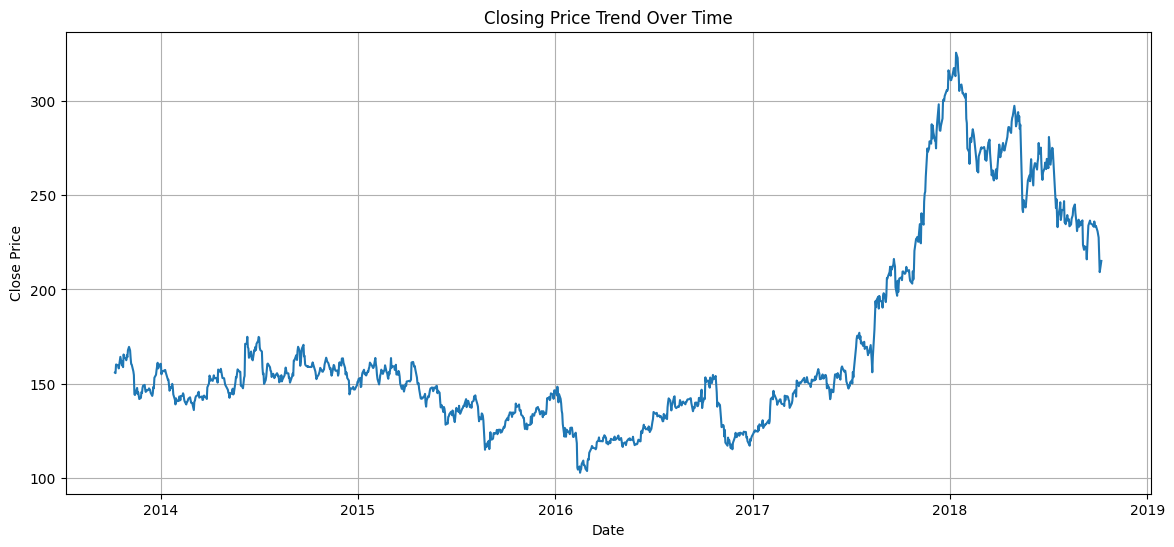

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(data["Date"], data["Close"])
plt.title("Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

#### ***5.2. Opening Price Trend Over Time***

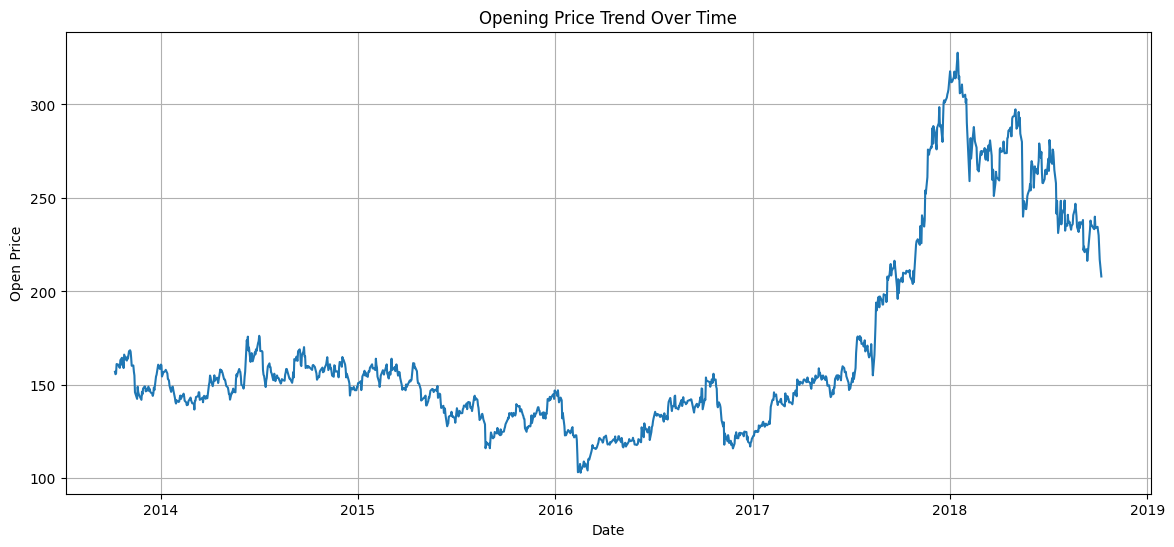

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(data["Date"], data["Open"])
plt.title("Opening Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Open Price")
plt.grid(True)
plt.show()

#### ***5.3. High & Low Price Trend Over Time***

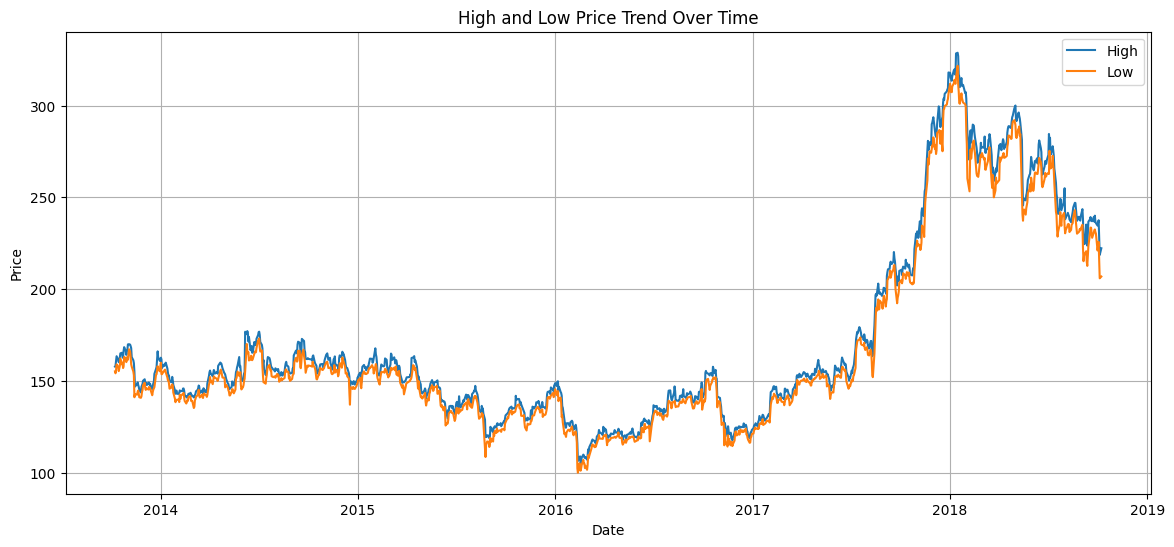

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(data["Date"], data["High"], label="High")
plt.plot(data["Date"], data["Low"], label="Low")
plt.title("High and Low Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

#### ***5.4. Trading Volume Trend Over Time***

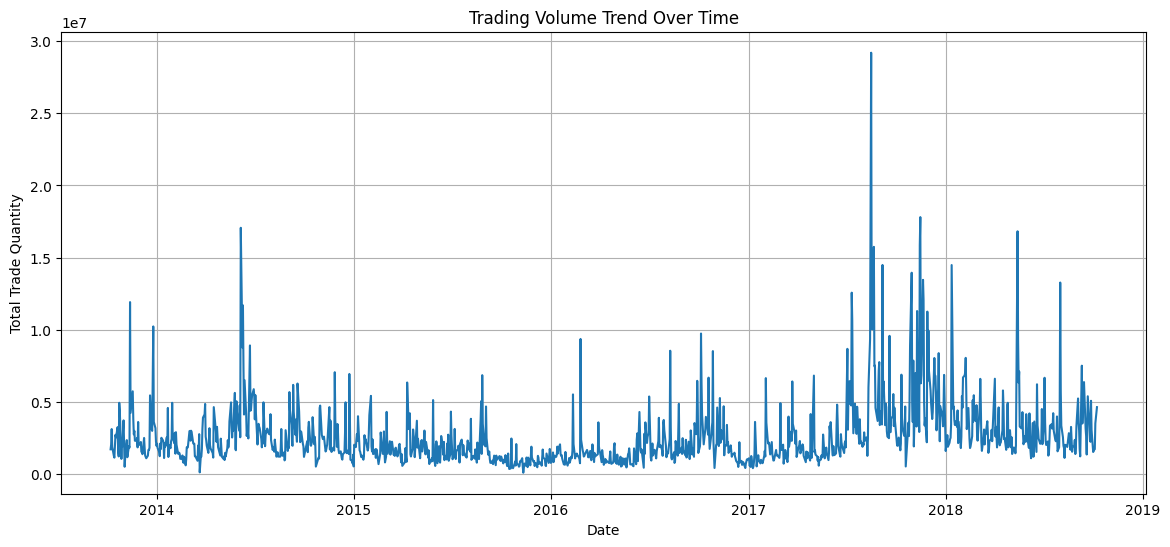

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(data["Date"], data["Total Trade Quantity"])
plt.title("Trading Volume Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Trade Quantity")
plt.grid(True)
plt.show()

#### ***5.5. Turnover Trend Over Time***

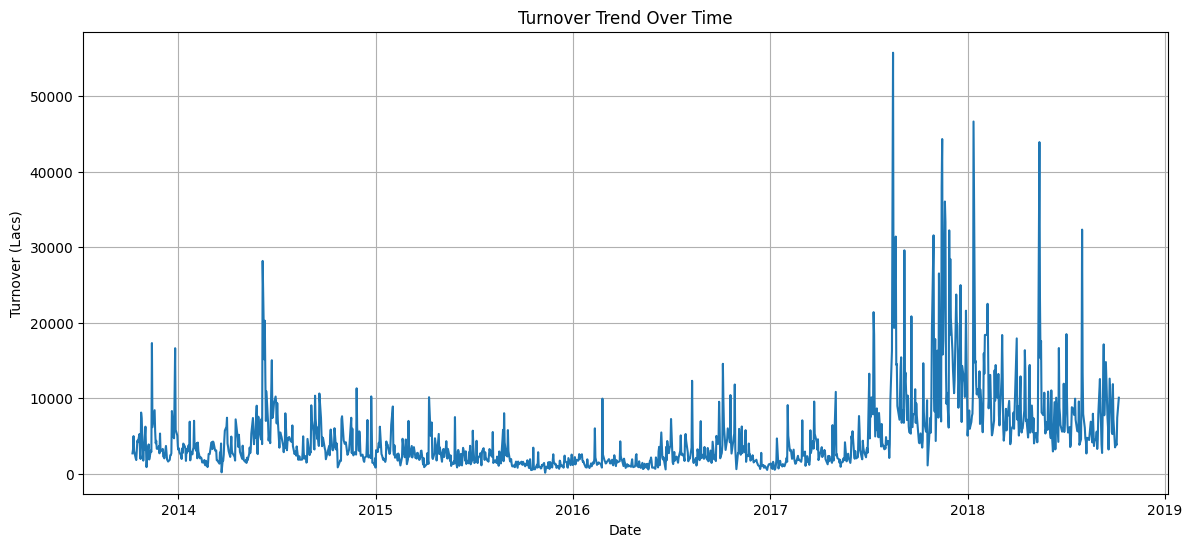

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(data["Date"], data["Turnover (Lacs)"])
plt.title("Turnover Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover (Lacs)")
plt.grid(True)
plt.show()

#### ***5.6. Distribution of Close Price***

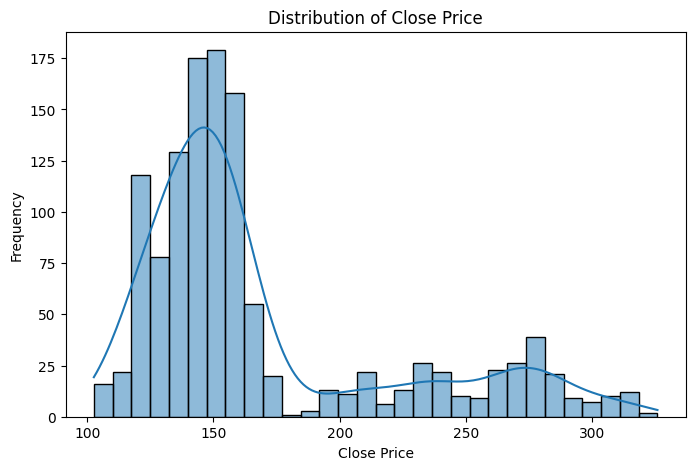

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Close"], bins=30, kde=True)
plt.title("Distribution of Close Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

#### ***5.7. Correlation Heatmap***

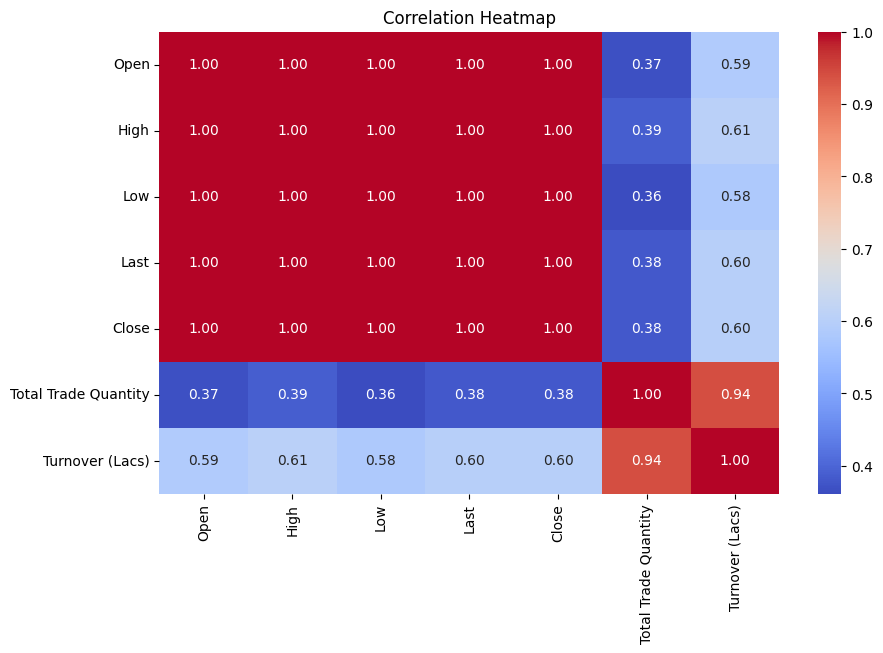

In [12]:
plt.figure(figsize=(10, 6))
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### ***5.8. Close Price with Moving Averages***

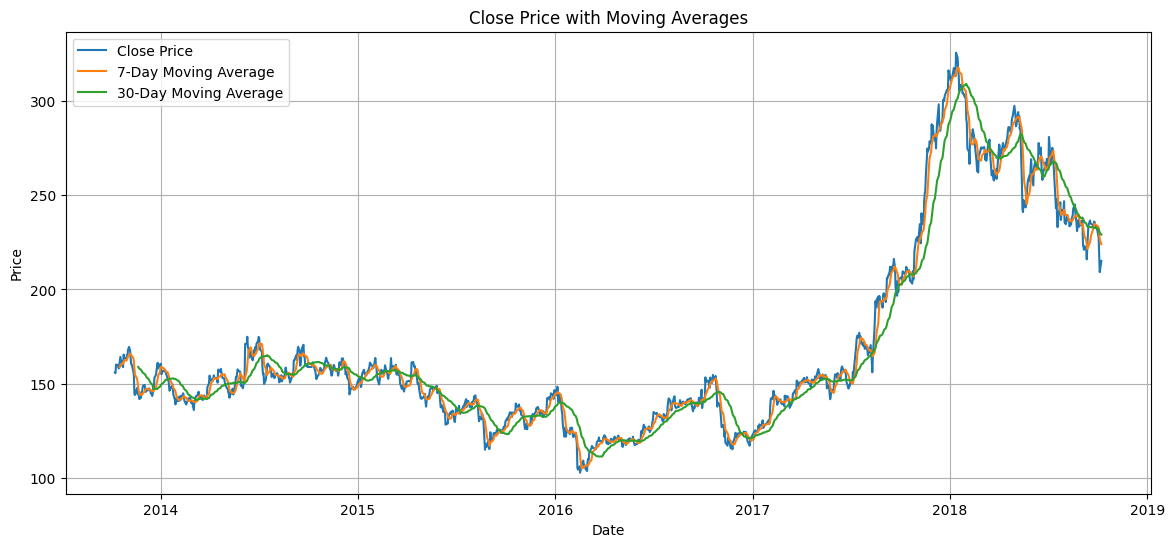

In [13]:
# Moving average visualization
data["MA_7_temp"] = data["Close"].rolling(window=7).mean()
data["MA_30_temp"] = data["Close"].rolling(window=30).mean()

plt.figure(figsize=(14, 6))
plt.plot(data["Date"], data["Close"], label="Close Price")
plt.plot(data["Date"], data["MA_7_temp"], label="7-Day Moving Average")
plt.plot(data["Date"], data["MA_30_temp"], label="30-Day Moving Average")
plt.title("Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# Remove temporary columns
data = data.drop(columns=["MA_7_temp", "MA_30_temp"])

## **6. Feature Engineering**



In [14]:
feature_data = data.copy()

# Create target column: next day close price
feature_data["Next_Close"] = feature_data["Close"].shift(-1)

# Daily price change
feature_data["Price_Change"] = feature_data["Close"] - feature_data["Open"]

# Daily return percentage
feature_data["Daily_Return_Percent"] = feature_data["Close"].pct_change() * 100

# Moving averages
feature_data["MA_7"] = feature_data["Close"].rolling(window=7).mean()
feature_data["MA_14"] = feature_data["Close"].rolling(window=14).mean()
feature_data["MA_30"] = feature_data["Close"].rolling(window=30).mean()

# Lag features
feature_data["Close_lag_1"] = feature_data["Close"].shift(1)
feature_data["Close_lag_2"] = feature_data["Close"].shift(2)
feature_data["Close_lag_3"] = feature_data["Close"].shift(3)
feature_data["Close_lag_7"] = feature_data["Close"].shift(7)

# Drop rows with NaN values created by rolling, lagging, and shifting
feature_data = feature_data.dropna().reset_index(drop=True)

print("Shape after feature engineering:", feature_data.shape)
display(feature_data.head())

Shape after feature engineering: (1205, 18)


,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs),Next_Close,Price_Change,Daily_Return_Percent,MA_7,MA_14,MA_30,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_7
0,2013-11-20,146.25,147.80,144.75,145.80,145.35,2756146.0,4034.80,143.65,-0.90,0.553442,148.135714,156.410714,158.838333,144.55,147.70,143.95,160.10
1,2013-11-21,145.10,146.80,143.10,144.10,143.65,2997918.0,4355.49,141.80,-1.45,-1.169591,146.292857,154.957143,158.433333,145.35,144.55,147.70,156.55
2,2013-11-22,144.35,145.20,141.10,142.35,141.80,2315264.0,3306.10,142.40,-2.55,-1.287852,144.471429,153.107143,157.975000,143.65,145.35,144.55,154.55
3,2013-11-25,142.55,143.75,140.80,142.50,142.40,2305892.0,3285.91,145.50,-0.15,0.423131,144.200000,151.171429,157.383333,141.80,143.65,145.35,144.30
4,2013-11-26,142.00,146.80,141.60,145.80,145.50,2505101.0,3641.28,145.05,3.50,2.176966,144.421429,149.592857,156.898333,142.40,141.80,143.65,143.95


## **7. Feature Selection**


In [15]:
# Feature columns
feature_columns = [
    "Open",
    "High",
    "Low",
    "Last",
    "Close",
    "Total Trade Quantity",
    "Turnover (Lacs)",
    "Price_Change",
    "Daily_Return_Percent",
    "MA_7",
    "MA_14",
    "MA_30",
    "Close_lag_1",
    "Close_lag_2",
    "Close_lag_3",
    "Close_lag_7"
]

target_column = "Next_Close"

X = feature_data[feature_columns]
y = feature_data[target_column]

print("Input Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nSelected Features:")
print(feature_columns)

display(X.head())

Input Features Shape: (1205, 16)
Target Shape: (1205,)

Selected Features:
['Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity', 'Turnover (Lacs)', 'Price_Change', 'Daily_Return_Percent', 'MA_7', 'MA_14', 'MA_30', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_7']


,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs),Price_Change,Daily_Return_Percent,MA_7,MA_14,MA_30,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_7
0,146.25,147.80,144.75,145.80,145.35,2756146.0,4034.80,-0.90,0.553442,148.135714,156.410714,158.838333,144.55,147.70,143.95,160.10
1,145.10,146.80,143.10,144.10,143.65,2997918.0,4355.49,-1.45,-1.169591,146.292857,154.957143,158.433333,145.35,144.55,147.70,156.55
2,144.35,145.20,141.10,142.35,141.80,2315264.0,3306.10,-2.55,-1.287852,144.471429,153.107143,157.975000,143.65,145.35,144.55,154.55
3,142.55,143.75,140.80,142.50,142.40,2305892.0,3285.91,-0.15,0.423131,144.200000,151.171429,157.383333,141.80,143.65,145.35,144.30
4,142.00,146.80,141.60,145.80,145.50,2505101.0,3641.28,3.50,2.176966,144.421429,149.592857,156.898333,142.40,141.80,143.65,143.95


## **8. Data Splitting**

- First 80% data → Training set  
- Last 20% data → Testing set

In [16]:
# Chronological train-test split
train_size = int(len(feature_data) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

train_dates = feature_data["Date"].iloc[:train_size]
test_dates = feature_data["Date"].iloc[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining date range:", train_dates.min(), "to", train_dates.max())
print("Testing date range:", test_dates.min(), "to", test_dates.max())

X_train shape: (964, 16)
X_test shape: (241, 16)
y_train shape: (964,)
y_test shape: (241,)

Training date range: 2013-11-20 00:00:00 to 2017-10-16 00:00:00
Testing date range: 2017-10-17 00:00:00 to 2018-10-05 00:00:00


## **9. Feature Scaling**
- `StandardScaler` inside pipelines for selected ML models  
- `MinMaxScaler` for LSTM and GRU sequence models

In [17]:
# Standard scaling for manual use if needed
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

# MinMax scaling for deep learning models
feature_scaler_dl = MinMaxScaler()
target_scaler_dl = MinMaxScaler()

X_all_scaled_dl = feature_scaler_dl.fit_transform(X)
y_all_scaled_dl = target_scaler_dl.fit_transform(y.values.reshape(-1, 1))

print("Scaling completed successfully.")

Scaling completed successfully.


## **10. Model Building**


In [18]:
# Machine Learning models
ml_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=10
    ),

    "Support Vector Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=100, gamma=0.01, epsilon=0.1))
    ]),

    "XGBoost Regressor": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        objective="reg:squarederror"
    ),

    "LightGBM Regressor": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        verbose=-1
    )
}

print("Machine Learning models created successfully.")

Machine Learning models created successfully.


In [19]:
# Function to create sequences for LSTM and GRU
def create_sequences(X_data, y_data, sequence_length=30):
    X_seq, y_seq = [], []
    for i in range(sequence_length, len(X_data)):
        X_seq.append(X_data[i-sequence_length:i])
        y_seq.append(y_data[i])
    return np.array(X_seq), np.array(y_seq)

sequence_length = 30

X_seq, y_seq = create_sequences(X_all_scaled_dl, y_all_scaled_dl, sequence_length)

seq_train_size = int(len(X_seq) * 0.80)

X_seq_train = X_seq[:seq_train_size]
X_seq_test = X_seq[seq_train_size:]

y_seq_train = y_seq[:seq_train_size]
y_seq_test = y_seq[seq_train_size:]

print("X_seq_train shape:", X_seq_train.shape)
print("X_seq_test shape:", X_seq_test.shape)
print("y_seq_train shape:", y_seq_train.shape)
print("y_seq_test shape:", y_seq_test.shape)

X_seq_train shape: (940, 30, 16)
X_seq_test shape: (235, 30, 16)
y_seq_train shape: (940, 1)
y_seq_test shape: (235, 1)


In [20]:
# LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mse")
    return model

# GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(32))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mse")
    return model

input_shape = (X_seq_train.shape[1], X_seq_train.shape[2])

lstm_model = build_lstm_model(input_shape)
gru_model = build_gru_model(input_shape)

print("LSTM and GRU models created successfully.")

LSTM and GRU models created successfully.


## **11. Model Training**


In [21]:
# Evaluation function
def evaluate_regression_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

# Train ML models
results = []
predictions = {}
trained_ml_models = {}

for model_name, model in ml_models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[model_name] = y_pred
    trained_ml_models[model_name] = model

    metrics = evaluate_regression_model(y_test, y_pred)
    metrics["Model"] = model_name
    results.append(metrics)

    print(f"{model_name} training completed.")
    print(metrics)
    print("-" * 60)

Training Linear Regression...
Linear Regression training completed.
{'MAE': 4.3832291649962345, 'MSE': 35.12175188936966, 'RMSE': np.float64(5.92636076267465), 'R2 Score': 0.9533093111843552, 'Model': 'Linear Regression'}
------------------------------------------------------------
Training Random Forest Regressor...
Random Forest Regressor training completed.
{'MAE': 57.47691704126307, 'MSE': 4051.4412829844905, 'RMSE': np.float64(63.65093308808984), 'R2 Score': -4.385966645244139, 'Model': 'Random Forest Regressor'}
------------------------------------------------------------
Training Support Vector Regressor...
Support Vector Regressor training completed.
{'MAE': 79.60736700268778, 'MSE': 8193.64448618405, 'RMSE': np.float64(90.51875212454075), 'R2 Score': -9.8925917526977, 'Model': 'Support Vector Regressor'}
------------------------------------------------------------
Training XGBoost Regressor...
XGBoost Regressor training completed.
{'MAE': 59.08146352174371, 'MSE': 4229.2844637

In [22]:
# Train LSTM and GRU models
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

epochs = 25
batch_size = 16

print("Training LSTM model...")
lstm_history = lstm_model.fit(
    X_seq_train,
    y_seq_train,
    validation_split=0.10,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining GRU model...")
gru_history = gru_model.fit(
    X_seq_train,
    y_seq_train,
    validation_split=0.10,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

Training LSTM model...
Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0040 - val_loss: 0.0047
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - val_loss: 0.0048
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013 - val_loss: 0.0039
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 0.0049
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.2856e-04 - val_loss: 0.0037
Epoch 6/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7031e-04 - val_loss: 0.0042
Epoch 7/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.4647e-04 - val_loss: 0.0043
Epoch 8/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.8688e-04 - val_loss: 0.0036
Epoch 9/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9413e-04 - val_loss: 0.0033
Epoch 10/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.0927e-04 - val_loss: 0.0046
Epoch 11/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.7910e-04 - val_loss: 0.0047
Epoch 12/25
53/53 

## **12. Model Evaluation**

- **MAE**: Mean Absolute Error  
- **MSE**: Mean Squared Error  
- **RMSE**: Root Mean Squared Error  
- **R2 Score**: Coefficient of determination

In [23]:
# Evaluate LSTM
lstm_pred_scaled = lstm_model.predict(X_seq_test)
lstm_pred = target_scaler_dl.inverse_transform(lstm_pred_scaled).flatten()
y_seq_test_actual = target_scaler_dl.inverse_transform(y_seq_test).flatten()

lstm_metrics = evaluate_regression_model(y_seq_test_actual, lstm_pred)
lstm_metrics["Model"] = "LSTM"
results.append(lstm_metrics)
predictions["LSTM"] = lstm_pred

print("LSTM Evaluation:")
print(lstm_metrics)

# Evaluate GRU
gru_pred_scaled = gru_model.predict(X_seq_test)
gru_pred = target_scaler_dl.inverse_transform(gru_pred_scaled).flatten()

gru_metrics = evaluate_regression_model(y_seq_test_actual, gru_pred)
gru_metrics["Model"] = "GRU"
results.append(gru_metrics)
predictions["GRU"] = gru_pred

print("\nGRU Evaluation:")
print(gru_metrics)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step
LSTM Evaluation:
{'MAE': 35.74259205919631, 'MSE': 1540.4391695206232, 'RMSE': np.float64(39.248428879645914), 'R2 Score': -1.2514327061634432, 'Model': 'LSTM'}
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step

GRU Evaluation:
{'MAE': 21.686102892287238, 'MSE': 571.4744437728251, 'RMSE': np.float64(23.90553165635153), 'R2 Score': 0.16476010289514087, 'Model': 'GRU'}


In [24]:
# Create comparison dataframe
comparison_df = pd.DataFrame(results)

# Arrange columns
comparison_df = comparison_df[["Model", "MAE", "MSE", "RMSE", "R2 Score"]]

# Sort by RMSE because lower RMSE is better
comparison_df = comparison_df.sort_values("RMSE").reset_index(drop=True)

display(comparison_df)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.383229,35.121752,5.926361,0.953309
1,GRU,21.686103,571.474444,23.905532,0.164760
2,LSTM,35.742592,1540.439170,39.248429,-1.251433
3,LightGBM Regressor,54.313123,3682.485340,60.683485,-3.895478
4,Random Forest Regressor,57.476917,4051.441283,63.650933,-4.385967
5,XGBoost Regressor,59.081464,4229.284464,65.032949,-4.622391
6,Support Vector Regressor,79.607367,8193.644486,90.518752,-9.892592


## **13. Performance Comparison**


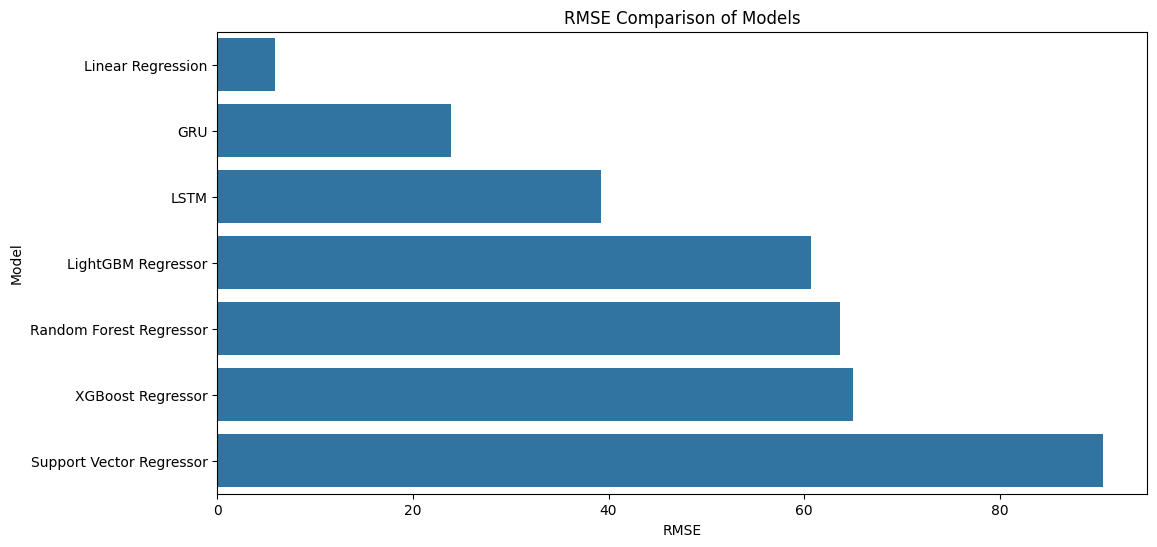

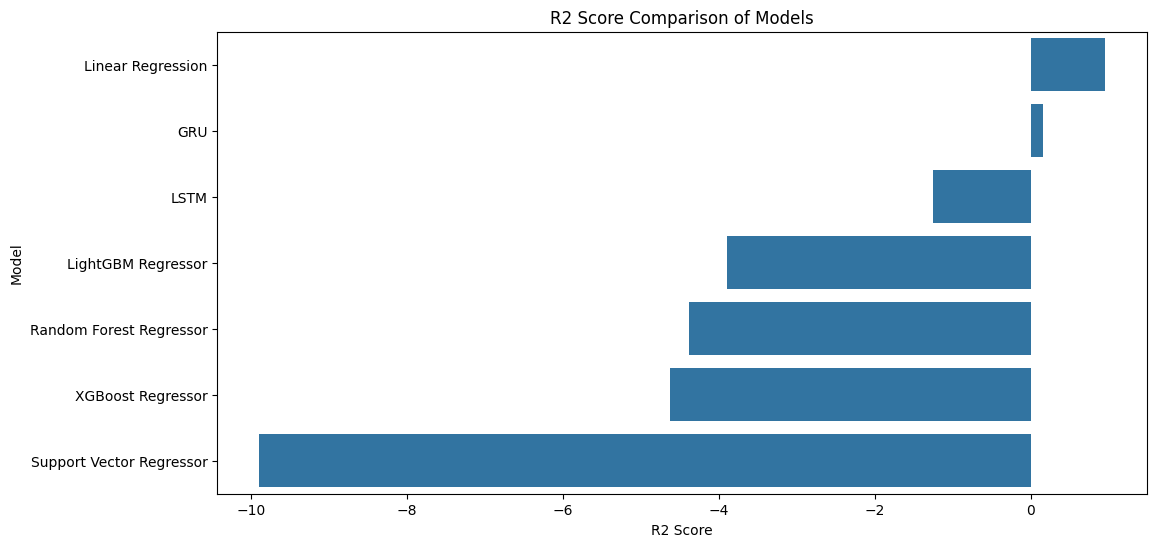

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="RMSE", y="Model")
plt.title("RMSE Comparison of Models")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="R2 Score", y="Model")
plt.title("R2 Score Comparison of Models")
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.show()

Best Model: Linear Regression


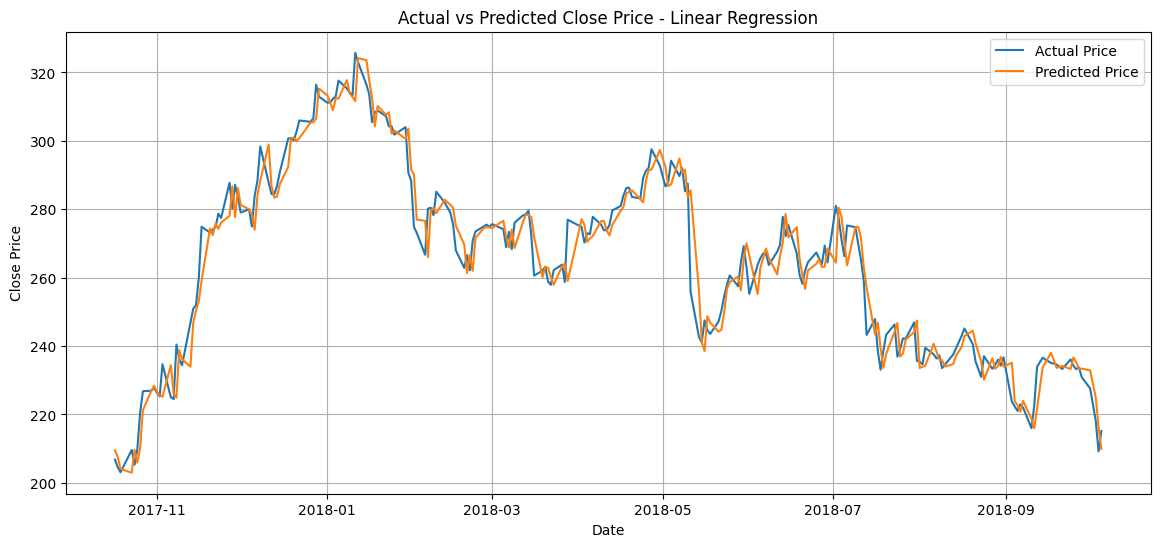

In [26]:
# Plot actual vs predicted prices for best model
best_model_name = comparison_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

if best_model_name in ["LSTM", "GRU"]:
    actual_for_plot = y_seq_test_actual
    predicted_for_plot = predictions[best_model_name]
    plot_dates = test_dates.iloc[-len(actual_for_plot):]
else:
    actual_for_plot = y_test.values
    predicted_for_plot = predictions[best_model_name]
    plot_dates = test_dates

plt.figure(figsize=(14, 6))
plt.plot(plot_dates, actual_for_plot, label="Actual Price")
plt.plot(plot_dates, predicted_for_plot, label="Predicted Price")
plt.title(f"Actual vs Predicted Close Price - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

## **14. Prediction Visualization**



In [27]:
# Create prediction results dataframe for the best model
if best_model_name in ["LSTM", "GRU"]:
    prediction_results = pd.DataFrame({
        "Date": list(plot_dates),
        "Actual_Close": actual_for_plot,
        "Predicted_Close": predicted_for_plot
    })
else:
    prediction_results = pd.DataFrame({
        "Date": list(test_dates),
        "Actual_Close": y_test.values,
        "Predicted_Close": predictions[best_model_name]
    })

prediction_results["Error"] = prediction_results["Actual_Close"] - prediction_results["Predicted_Close"]

display(prediction_results.head(10))
display(prediction_results.tail(10))

,Date,Actual_Close,Predicted_Close,Error
0,2017-10-17,206.80,209.542995,-2.742995
1,2017-10-18,204.60,207.578770,-2.978770
2,2017-10-19,203.10,204.093518,-0.993518
3,2017-10-23,209.65,202.977863,6.672137
4,2017-10-24,205.30,209.702876,-4.402876
5,2017-10-25,209.80,205.918497,3.881503
6,2017-10-26,220.50,210.158597,10.341403
7,2017-10-27,226.80,221.268455,5.531545
8,2017-10-30,226.95,226.889876,0.060124
9,2017-10-31,227.80,228.404450,-0.604450


,Date,Actual_Close,Predicted_Close,Error
231,2018-09-21,233.30,234.188801,-0.888801
232,2018-09-24,236.10,233.302131,2.797869
233,2018-09-25,234.25,236.680248,-2.430248
234,2018-09-26,233.25,235.281552,-2.031552
235,2018-09-27,233.75,233.326612,0.423388
236,2018-09-28,230.90,233.418614,-2.518614
237,2018-10-01,227.60,232.886684,-5.286684
238,2018-10-03,218.20,225.003301,-6.803301
239,2018-10-04,209.20,216.386092,-7.186092
240,2018-10-05,215.15,209.927845,5.222155


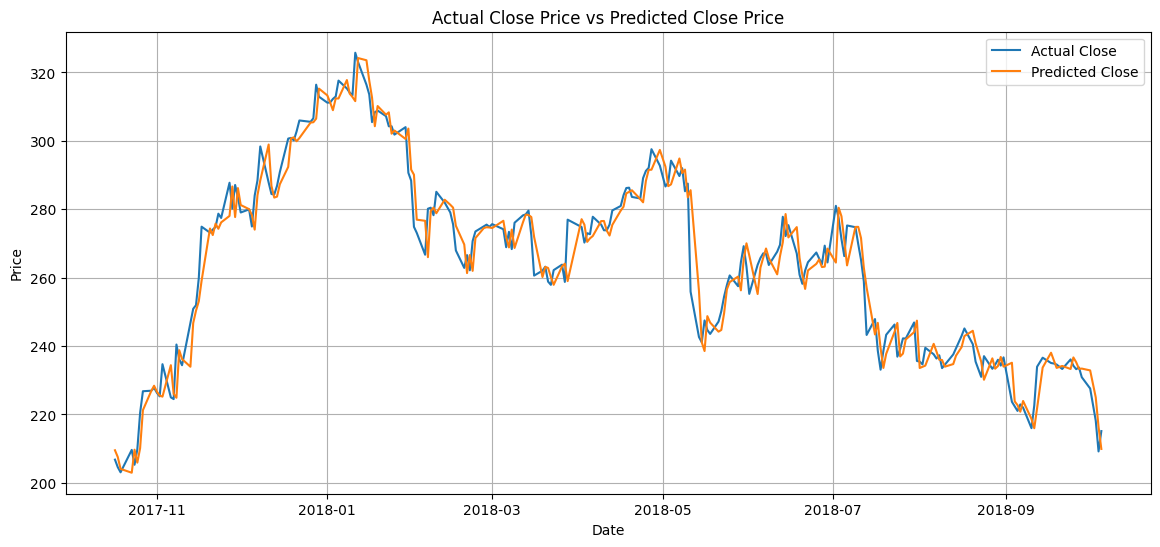

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(prediction_results["Date"], prediction_results["Actual_Close"], label="Actual Close")
plt.plot(prediction_results["Date"], prediction_results["Predicted_Close"], label="Predicted Close")
plt.title("Actual Close Price vs Predicted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## **15. Future Price Prediction System**


In [30]:
# Use best ML model for one-row future prediction.
# If the overall best model is LSTM or GRU, we still use the best ML model for simple tabular next-day prediction.

ml_comparison = comparison_df[comparison_df["Model"].isin(trained_ml_models.keys())].copy()
best_ml_model_name = ml_comparison.sort_values("RMSE").iloc[0]["Model"]
best_ml_model = trained_ml_models[best_ml_model_name]

print("Best ML Model for future one-row prediction:", best_ml_model_name)

# Latest row from feature data
latest_row = feature_data.iloc[-1]
latest_features = latest_row[feature_columns].to_frame().T

predicted_next_close = best_ml_model.predict(latest_features)[0]
current_close = latest_row["Close"]
change = predicted_next_close - current_close
change_percent = (change / current_close) * 100

print("Current Close Price:", round(current_close, 2))
print("Predicted Next Close Price:", round(predicted_next_close, 2))
print("Expected Change:", round(change, 2))
print("Expected Change Percentage:", round(change_percent, 2), "%")

if change > 0:
    print("Prediction: Stock price may increase.")
elif change < 0:
    print("Prediction: Stock price may decrease.")
else:
    print("Prediction: Stock price may remain stable.")

Best ML Model for future one-row prediction: Linear Regression
Current Close Price: 209.2
Predicted Next Close Price: 209.93
Expected Change: 0.73
Expected Change Percentage: 0.35 %
Prediction: Stock price may increase.


## **16. Save Models**


In [31]:
# Create output directory
OUTPUT_DIR = "stock_prediction_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save best ML model
joblib.dump(best_ml_model, os.path.join(OUTPUT_DIR, "best_ml_stock_price_model.pkl"))

# Save scalers
joblib.dump(standard_scaler, os.path.join(OUTPUT_DIR, "standard_scaler.pkl"))
joblib.dump(feature_scaler_dl, os.path.join(OUTPUT_DIR, "feature_scaler_dl.pkl"))
joblib.dump(target_scaler_dl, os.path.join(OUTPUT_DIR, "target_scaler_dl.pkl"))

# Save feature columns
joblib.dump(feature_columns, os.path.join(OUTPUT_DIR, "feature_columns.pkl"))

# Save deep learning models
lstm_model.save(os.path.join(OUTPUT_DIR, "lstm_stock_price_model.keras"))
gru_model.save(os.path.join(OUTPUT_DIR, "gru_stock_price_model.keras"))

# Save result CSV files
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "model_performance_comparison.csv"), index=False)
prediction_results.to_csv(os.path.join(OUTPUT_DIR, "prediction_results.csv"), index=False)

print("Models and result files saved successfully in:", OUTPUT_DIR)

Models and result files saved successfully in: stock_prediction_outputs
